# Getting the dataset

In [2]:
import urllib.request
import os


In [3]:
# If file does not exists, then make it otherwise do not make another file
url = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/master/KDDTrain%2B.txt"
file_name = "KDDTrain+.txt"

if not os.path.exists(file_name):
    print("Downloading dataset... please wait.")
    urllib.request.urlretrieve(url, file_name)
    print("Download Complete!")
else:
    print("File already exists in your folder. You're good to go!")

File already exists in your folder. You're good to go!


# Analyzing the dataset

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set(style="whitegrid")
%matplotlib inline

In [5]:
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
           "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
           "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
           "num_shells","num_access_files","num_outbound_cmds","is_host_login",
           "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
           "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
           "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
           "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]
# Load the dataset
df = pd.read_csv("KDDTrain+.txt", names=columns)

# Drop the difficulty level 
df.drop(['difficulty_level'], axis=1, inplace=True)

print(f"Dataset Loaded: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset Loaded: 125973 rows and 42 columns


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


label
0    67343
1    58630
Name: count, dtype: int64


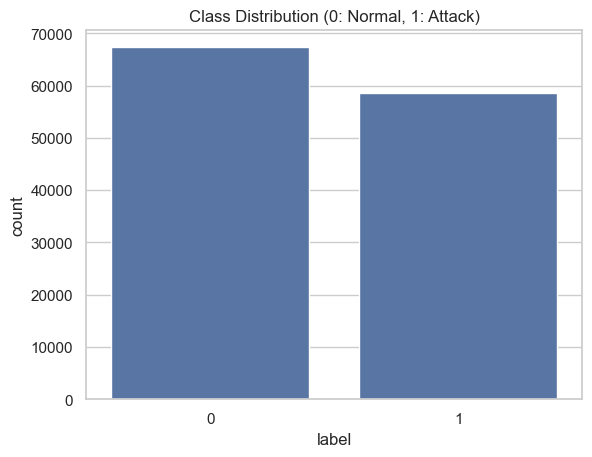

In [6]:
df['label'] = df['label'].apply(lambda x:0 if x=='normal' else 1)
print(df['label'].value_counts())
sns.countplot(x='label', data=df)
plt.title("Class Distribution (0: Normal, 1: Attack)")
plt.show()

In [7]:
# to see strings and convert in number as ML algorithm understands numbers better
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
# Value dont get ranked
df = pd.get_dummies(df, columns=['protocol_type', 'flag'])
# Values gets reranked
df['service'] = le.fit_transform(df['service'])
df['label'] = le.fit_transform(df['label'])

print("hybrid model successfully created")

hybrid model successfully created


In [8]:
df.to_csv("cleaned_data.csv",index=False)

In [10]:
df.columns.tolist()

['duration',
 'service',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'label',
 'protocol_type_icmp',
 'protocol_type_tcp',
 'protocol_type_udp',
 'flag_OTH',
 'flag_REJ',
 'flag_RSTO',
 'flag_RSTOS0',
 'flag_RSTR',
 'flag_S0',
 'flag_S1',
 'flag_S2',
 'flag_S3',
 'flag_SF',
 'flag_SH']

# Feature Engineering and Data Scaling
In cybersecurity, raw numbers can be misleading. For example, src_bytes might be in the millions, while num_failed_logins is only 1 or 2. If you feed this directly into your AI, the model will think src_bytes is "more important" just because the numbers are bigger. We need to normalize them.

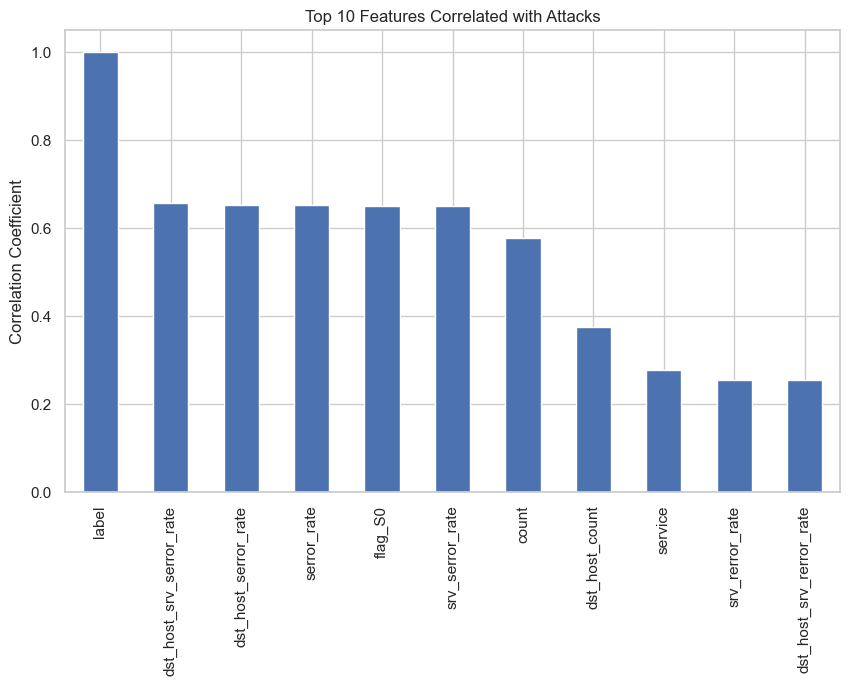

In [60]:
# Correlations so that bigger data should not get high priority blindly
correlations = df.corr()['label'].sort_values(ascending=False)
# Plot 10 features
plt.figure(figsize=(10,6))
correlations.head(11).plot(kind='bar')
plt.title("Top 10 Features Correlated with Attacks")
plt.ylabel("Correlation Coefficient")
plt.show()

Split the data

In [62]:
from sklearn.model_selection import train_test_split

In [67]:
# X features
# y features
X = df.drop(['label'], axis=1)
y = df['label']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (100778, 53)
Testing shape: (25195, 53)


Scale the data

In [69]:
scaler = StandardScaler()

# Fit only on the training data to avoid 'Data Leakage'
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Data Scaling Complete!")

Data Scaling Complete!


In [66]:
scaler = StandardScaler()

# Fit only on the training data to avoid 'Data Leakage'
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Data Scaling Complete!")

Data Scaling Complete!


Save the scaler

In [72]:
import joblib

In [73]:
# Save the scaler to use in our Flask app later
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


# Reshaping the data
To make it suitable for LTSM we change the shape

In [75]:
# We'll treat each packet as 1 time step with all its features
X_train_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"Original shape: {X_train_scaled.shape}")
print(f"LSTM shape: {X_train_lstm.shape}")

Original shape: (100778, 53)
LSTM shape: (100778, 1, 53)


In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

In [77]:
# Initialize the model
model = Sequential()

# Input Layer + First LSTM Layer
model.add(Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2)) # Prevents overfitting

# Second LSTM Layer
model.add(LSTM(units=32))
model.add(Dropout(0.2))

# Output Layer (Sigmoid is best for 0 or 1 classification)
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 64)               │          30,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,657 (166.63 KB)

 Trainable params: 42,657 (166.63 KB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [78]:
# Train the model
history = model.fit(
    X_train_lstm, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, # Uses 10% of training data for real-time testing
    verbose=1
)

Epoch 1/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9758 - loss: 0.0780 - val_accuracy: 0.9892 - val_loss: 0.0277
Epoch 2/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0263 - val_accuracy: 0.9910 - val_loss: 0.0226
Epoch 3/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9911 - loss: 0.0225 - val_accuracy: 0.9919 - val_loss: 0.0226
Epoch 4/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9922 - loss: 0.0208 - val_accuracy: 0.9933 - val_loss: 0.0201
Epoch 5/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9927 - loss: 0.0198 - val_accuracy: 0.9936 - val_loss: 0.0190
Epoch 6/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9930 - loss: 0.0186 - val_accuracy: 0.9942 - val_loss: 0.0183
Epoch 7/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9933 - loss: 0.0175 - val_accuracy: 0.9923 - val_loss: 0.0200
Epoch 8/10
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9934 - loss: 0.0170 - 

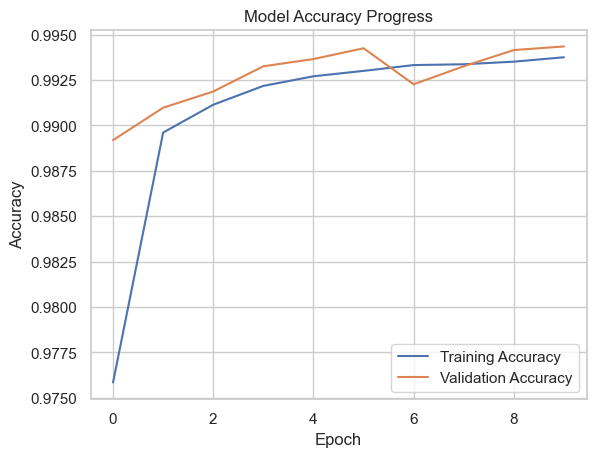

In [79]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Evaluating the testing data

In [80]:
y_pred_prob = model.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("Predictions completed.")

788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Predictions completed.


## Making a confusion matrix

In [81]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

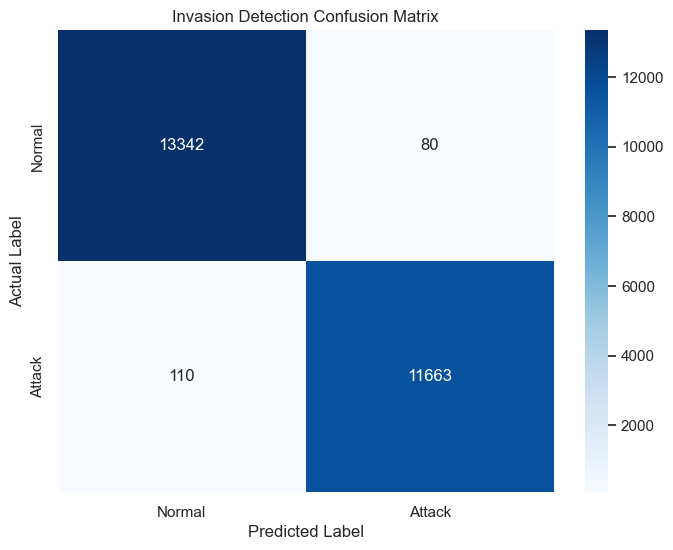

In [82]:
# Create the matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting it nicely
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Invasion Detection Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Classification report 

In [83]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13422
      Attack       0.99      0.99      0.99     11773

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



In [85]:
# Save the final model architecture and weights
model.save('ids_model.keras') 
print("Model saved as ids_model.keras")

Model saved as ids_model.keras
